# Plot results for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import datetime
import os
import pickle
import pprint
import time

import matplotlib as mpl
from matplotlib import cm
import numpy as np
import tensorflow as tf
from sklearn import preprocessing
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats


import experiment_settings
from build_data import build_hurricane_data
import shash_tfp
from toolbox import custom_round
import prediction

from silence_tensorflow import silence_tensorflow
silence_tensorflow()

In [28]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "29 July 2022"

import sys
sys.path.append('../')
DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis_plots/"
dpiFig = 300.
mpl.rcParams["figure.facecolor"] = "white"
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

# EXP_NAME_dx = "longitude301_EPCP48"
# EXP_NAME_dy = "latitude301_EPCP48"

EXP_NAME_dx = "longitude303_EPCP48"
EXP_NAME_dy = "latitude303_EPCP48"

# EXP_NAME_dx = "longitude202_AL48"
# EXP_NAME_dy = "latitude202_AL48"


RNG_SEED = 123
TESTING_YEAR = 2018


In [3]:
# LATITUDE PREDICTIONS
settings = experiment_settings.get_settings(EXP_NAME_dy)

settings['rng_seed'] = RNG_SEED
settings["years_test"] = (TESTING_YEAR,)
(
    data_summary,        
    x_train_dy,
    onehot_train_dy,
    x_val_dy,
    onehot_val_dy,
    x_test_dy,
    onehot_test_dy,        
    x_valtest_dy,
    onehot_valtest_dy,
    df_train_dy,
    df_val_dy,
    df_test_dy,
    df_valtest_dy,
) = build_hurricane_data(DATA_PATH, settings, verbose=2)

# load the model
model_name = (
    EXP_NAME_dy + "_" + 
    str(TESTING_YEAR) + '_' +
    settings["uncertainty_type"] + '_' + 
    f"network_seed_{settings['rng_seed']}_rng_seed_{settings['rng_seed']}"
)
model_dy     = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
(
    mu_pred_dy, 
    sigma_pred_dy, 
    gamma_pred_dy, 
    tau_pred_dy,    
) = prediction.params(x_test_dy, model_dy)    

# convert y_pred to position corrections
ann_correction_dy  = prediction.percentile_value(mu_pred_dy, sigma_pred_dy, gamma_pred_dy, tau_pred_dy, percentile_frac=.5)
true_correction_dy = df_test_dy['OBDY'].to_numpy() 
cons_correction_dy = np.zeros(np.shape(true_correction_dy))

# covert ann prediction bounds
ann_low_correction_dy  = prediction.percentile_value(mu_pred_dy, sigma_pred_dy, gamma_pred_dy, tau_pred_dy, percentile_frac=.25)
ann_high_correction_dy = prediction.percentile_value(mu_pred_dy, sigma_pred_dy, gamma_pred_dy, tau_pred_dy, percentile_frac=.75)
iqr_dy                 = ann_high_correction_dy - ann_low_correction_dy

# ann_low_correction_dy  = prediction.mean(mu_pred_dy, sigma_pred_dy, gamma_pred_dy, tau_pred_dy)
# ann_high_correction_dy = prediction.mean(mu_pred_dy, sigma_pred_dy, gamma_pred_dy, tau_pred_dy)
# iqr_dy                 = ann_high_correction_dy - ann_low_correction_dy

# compute errors
ann_error_dy           = np.abs(ann_correction_dy - true_correction_dy)
cons_error_dy          = np.abs(cons_correction_dy - true_correction_dy)

years(2018,) withheld for testing
{'datafile_path': '../data/nnfit_vlist_02-Jun-2022.dat',
 'onehot_test_shape': (391, 2),
 'onehot_train_shape': (1592, 2),
 'onehot_val_shape': (200, 2),
 'x_names': ['NCT',
             'VMAX0',
             'AVDY',
             'EMDY',
             'EGDY',
             'HWDY',
             'LONC',
             'LATC',
             'VMXC',
             'DV12',
             'SLAT',
             'SHDC',
             'SSTN',
             'DTL'],
 'x_test_shape': (391, 14),
 'x_train_shape': (1592, 14),
 'x_val_shape': (200, 14),
 'y_name': ['OBDY']}


         |   cnt |    min |   25% |   50% |   75% |   max |   avg |   std |   iqr
---------+-------+--------+-------+-------+-------+-------+-------+-------+-------
 y_train |  1592 | -244.4 | -51.8 |   0.0 |  47.2 | 614.8 |  2.70 | 84.46 |  99.0
 y_val   |   200 | -266.6 | -53.5 |   0.0 |  49.3 | 372.2 |  0.27 | 84.13 | 102.8
 y_test  |   391 | -255.5 | -50.0 |  -3.7 |  44.4 | 248.1 | -2.77 | 74.29 |  94.4

In [4]:
# LONGITUDE PREDICTIONS
settings = experiment_settings.get_settings(EXP_NAME_dx)

settings['rng_seed'] = RNG_SEED
settings["years_test"] = (TESTING_YEAR,)
(
    data_summary,        
    x_train_dx,
    onehot_train_dx,
    x_val_dx,
    onehot_val_dx,
    x_test_dx,
    onehot_test_dx,        
    x_valtest_dx,
    onehot_valtest_dx,
    df_train_dx,
    df_val_dx,
    df_test_dx,
    df_valtest_dx,
) = build_hurricane_data(DATA_PATH, settings, verbose=2)

# load the model
model_name = (
    EXP_NAME_dx + "_" + 
    str(TESTING_YEAR) + '_' +
    settings["uncertainty_type"] + '_' + 
    f"network_seed_{settings['rng_seed']}_rng_seed_{settings['rng_seed']}"
)
model_dx = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
(
    mu_pred_dx, 
    sigma_pred_dx, 
    gamma_pred_dx, 
    tau_pred_dx,    
) = prediction.params(x_test_dx, model_dx)    

# convert y_pred to position corrections
ann_correction_dx  = prediction.percentile_value(mu_pred_dx, sigma_pred_dx, gamma_pred_dx, tau_pred_dx, percentile_frac=.5)
true_correction_dx = df_test_dx['OBDX'].to_numpy() 
cons_correction_dx = np.zeros(np.shape(true_correction_dx))

# covert ann prediction bounds
ann_low_correction_dx  = prediction.percentile_value(mu_pred_dx, sigma_pred_dx, gamma_pred_dx, tau_pred_dx, percentile_frac=.25)
ann_high_correction_dx = prediction.percentile_value(mu_pred_dx, sigma_pred_dx, gamma_pred_dx, tau_pred_dx, percentile_frac=.75)
iqr_dx                 = ann_high_correction_dx - ann_low_correction_dx

# ann_low_correction_dx  = prediction.mean(mu_pred_dx, sigma_pred_dx, gamma_pred_dx, tau_pred_dx)
# ann_high_correction_dx = prediction.mean(mu_pred_dx, sigma_pred_dx, gamma_pred_dx, tau_pred_dx)
# iqr_dx                 = ann_high_correction_dx - ann_low_correction_dx

# compute errors
ann_error_dx           = np.abs(ann_correction_dx - true_correction_dx)
cons_error_dx          = np.abs(cons_correction_dx - true_correction_dx)

years(2018,) withheld for testing
{'datafile_path': '../data/nnfit_vlist_02-Jun-2022.dat',
 'onehot_test_shape': (391, 2),
 'onehot_train_shape': (1592, 2),
 'onehot_val_shape': (200, 2),
 'x_names': ['NCT',
             'VMAX0',
             'AVDX',
             'EMDX',
             'EGDX',
             'HWDX',
             'LONC',
             'LATC',
             'VMXC',
             'DV12',
             'SLAT',
             'SHDC',
             'SSTN',
             'DTL'],
 'x_test_shape': (391, 14),
 'x_train_shape': (1592, 14),
 'x_val_shape': (200, 14),
 'y_name': ['OBDX']}


         |   cnt |    min |   25% |   50% |   75% |   max |   avg |   std |   iqr
---------+-------+--------+-------+-------+-------+-------+-------+-------+-------
 y_train |  1592 | -387.5 | -44.8 |  13.2 |  70.2 | 390.6 | 12.25 | 94.17 | 115.1
 y_val   |   200 | -313.3 | -45.8 |  12.7 |  71.7 | 322.4 | 12.87 | 96.13 | 117.5
 y_test  |   391 | -319.1 | -53.3 |  -2.6 |  42.7 | 147.7 | -8.60 | 75.66 |  96.0

In [5]:
MODEL_NAME = ('track_' + 
              EXP_NAME_dy + '_' + 
              EXP_NAME_dx + "_" + 
              str(TESTING_YEAR) + '_' +
              settings["uncertainty_type"] + '_' +           
              f"network_seed_{settings['rng_seed']}_rng_seed_{settings['rng_seed']}")

# compute ann uncertainties to uncertainty defined by diagonal of box
iqr_diag = np.sqrt( iqr_dx**2 + iqr_dy**2 )

# compute errors
ann_error  = np.sqrt( ann_error_dy**2 + ann_error_dx**2 )
cons_error = np.sqrt( cons_error_dy**2 + cons_error_dx**2 )

ann_mae    = np.mean(np.abs(ann_error))
cons_mae   = np.mean(np.abs(cons_error))

print(ann_mae, cons_mae)
print('percent improvement by ANN = ' + str(np.round(100.*(cons_mae-ann_mae)/cons_mae,2)) + '%')

93.9831177126039 91.46253430848351
percent improvement by ANN = -2.76%


In [6]:
ann_error

array([ 12.36373958,  64.01540083,  58.35873097, 110.89255892,
       197.45501859, 181.95017803,  98.16002354,  66.30756408,
        68.21214583,  36.62977766, 132.21950471,  69.31310975,
        46.33529246,  65.63724   , 125.50426616,  33.29592034,
       143.5773463 ,  32.47232716,  83.84198407,  99.98860086,
       104.52144201,  81.1241371 ,  92.02812413, 120.28322572,
       103.18402474,  87.79967648,  55.56324017,  84.8676344 ,
        72.5942302 , 150.48837863,  19.0262982 ,  62.03043412,
       136.57850191,   7.98882621,  76.39258297, 287.73601653,
       246.493578  , 158.46175967, 106.8734407 ,  54.68489193,
       124.0803961 , 145.04487634,  85.18244973,  96.36804736,
       135.15014555, 105.05819166, 102.50219176,  72.50626645,
       120.23344886,  90.17902014,  56.01266057, 230.47030496,
        39.27367014, 181.80159596, 122.81790153, 154.64640997,
       111.41553752, 115.86608731,  40.84665868,  70.81943121,
        73.62300823,  77.14869228, 136.44881044,  75.37

# Plots

In [7]:
N_COLORS = 50
colors = ('#D95980','#284E60','#284E60','#C3B1E1','#351F27','#A9C961')

### for white background...
plt.rc('text',usetex=True)
plt.rc('font',**{'family':'sans-serif','sans-serif':['Avant Garde']}) 
plt.rc('savefig',facecolor='white')
plt.rc('axes',facecolor='white')
plt.rc('axes',labelcolor='dimgrey')
plt.rc('axes',labelcolor='dimgrey')
plt.rc('xtick',color='dimgrey')
plt.rc('ytick',color='dimgrey')
################################  
################################  
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 5))
        else:
            spine.set_color('none')  
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
            ax.xaxis.set_ticks([]) 
            
def format_spines(ax):
    adjust_spines(ax, ['left', 'bottom'])
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('dimgrey')
    ax.spines['bottom'].set_color('dimgrey')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params('both',length=4,width=2,which='major',color='dimgrey')
#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)                

In [8]:
def plot_iqr_vs_error(ax, model, x_eval, onehot_eval, df_eval, yvar="shash_error"):
    # make predictions
    mu_pred, sigma_pred, gamma_pred, tau_pred = prediction.params(x_eval, model)    

    # convert y_pred to intensity corrections    
    ann_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.5)
    true_correction = df_eval['OBDV'].to_numpy()  

    # convert to full intensity predictions
    cons_intensity  = df_eval['VMXC'].to_numpy()
    ann_intensity   = cons_intensity + ann_correction
    true_intensity  = cons_intensity + true_correction

    # compute errors
    shash_error  = np.abs(ann_intensity - true_intensity)
    cons_error = np.abs(cons_intensity - true_intensity)

    # covert shash prediction bounds
    shash_low_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.25)
    shash_high_correction = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.75)
    iqr                   = shash_high_correction - shash_low_correction

    print(stats.spearmanr(iqr,shash_error))
    print(stats.pearsonr(iqr,shash_error))

    df_eval['iqr'] = iqr
    df_eval['shash_error'] = shash_error
    df_eval['cons_error'] = cons_error

    #------------------------------------------------------------------------------------
    ROUND_BASE = 50

    df_plot = df_eval.copy()
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: custom_round(x, base=ROUND_BASE))
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: ceiling_round(x, ceiling=200))
    #-----------------------------------------------------------------------------
    clr = colors[0]
    if(yvar=="cons_error"):
        clr =colors[1]
    
    for xvar in ('iqr',):#('sigma', 'range_66'):
        g = sns.boxplot(
            ax=ax,
            data=df_plot,
            x=xvar, y=yvar,
            whis=None,
            fliersize=0,
            boxprops={'alpha':.2,
                      'edgecolor': 'gray',
                      'color': 'gray',
                     },
        )      
        plt.setp(g.artists, edgecolor = '.4', facecolor='.95')
        plt.setp(g.lines, color='.4')
        ax = sns.stripplot(ax=ax,x=xvar, y=yvar, data=df_plot, color=clr, size=3.,alpha=.75,)
        # plt.axhline(y=0,color='k', alpha=.25, linewidth=1)

        # g.set_xlim(-.5,6.5)

        ax.set_xlabel('Predicted IQR [km]')
        if(yvar=="cons_error"):
            ax.set_title('(b) Consensus Error vs SHASH Predicted Uncertainty', fontsize=FS*.9, color='k')    
            ax.set_ylabel('Absolute Error [km]')
        else:
            ax.set_title('(a) SHASH Error vs SHASH Predicted Uncertainty', fontsize=FS*.9, color='k')            
            ax.set_ylabel('Absolute Error [km]')        



## Latitude + Longitude

In [9]:
data = np.concatenate((
                       mu_pred_dx[:,np.newaxis], 
                       sigma_pred_dx[:,np.newaxis], 
                       gamma_pred_dx[:,np.newaxis],           
                       tau_pred_dx[:,np.newaxis],

                       mu_pred_dy[:,np.newaxis], 
                       sigma_pred_dy[:,np.newaxis], 
                       gamma_pred_dy[:,np.newaxis],           
                       tau_pred_dy[:,np.newaxis],

                       iqr_diag[:,np.newaxis],
                       
                       ann_error[:,np.newaxis],
                       cons_error[:,np.newaxis],
                       
                       ann_low_correction_dx[:,np.newaxis],
                       ann_high_correction_dx[:,np.newaxis],
                       ann_low_correction_dy[:,np.newaxis],
                       ann_high_correction_dy[:,np.newaxis],
                       
                       iqr_dx[:,np.newaxis],
                       iqr_dy[:,np.newaxis],
                       
                      ),
                      axis=1)

all_names = []#data_summary['x_names'].copy()
for a in ('mu_pred_dx', 
          'sigma_pred_dx', 
          'gamma_pred_dx', 
          'tau_pred_dx', 
          'mu_pred_dy', 
          'sigma_pred_dy', 
          'gamma_pred_dy', 
          'tau_pred_dy',          
          'iqr_diag', 
          'ann_error', 
          'cons_error',
          'ann_low_correction_dx',
          'ann_high_correction_dx',
          'ann_low_correction_dy',
          'ann_high_correction_dy',   
          'iqr_dx',
          'iqr_dy',
         ):
    all_names.append(a)
df = pd.DataFrame(data=data, columns=all_names)

## Single Latitude / Longitude

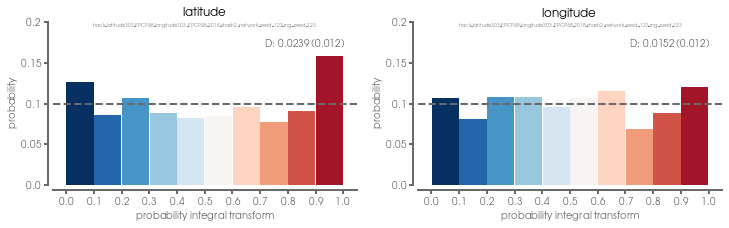

In [10]:
import model_diagnostics
FS = 12

cmap_interp = cm.get_cmap('RdBu_r', N_COLORS)    
norm = mpl.colors.Normalize(vmin=0, vmax=10)

fig = plt.figure(figsize=(12, 3.))
spec = fig.add_gridspec(1,2)

for itype,track_type in enumerate(('latitude','longitude')):
    
    if track_type == 'latitude':
        x_data = x_valtest_dy
        onehot = onehot_valtest_dy
        model = model_dy        
    elif track_type == 'longitude':
        x_data = x_valtest_dx     
        onehot = onehot_valtest_dx
        model = model_dx
    
    bins, hist_shash, D_shash, EDp_shash = model_diagnostics.compute_pit('shash',onehot, x_data=x_data,model_shash=model)
    bins_inc = bins[1]-bins[0]
    
    ax = fig.add_subplot(spec[0,itype])
    for ibar in np.arange(0,len(bins)-1):
        plt.bar(bins[ibar]+bins_inc/2,
                 hist_shash[0][ibar],
                 width=bins_inc*.98,
                 color=cmap_interp(norm(ibar)),
                 label='SHASH',
                )
    ax.axhline(y=.1, 
                linestyle='--',
                color='dimgray', 
                linewidth=2.,
               )
    plt.ylim(0,.2)
    plt.xticks(bins,np.around(bins,1))
    ax = plt.gca()
    yticks = np.around(np.arange(0,.25,.05),2)
    plt.yticks(yticks,yticks)

    plt.text(1.,np.max(yticks)*.9,
             'D: ' + str(np.round(D_shash,4)) + ' (' + str(np.round(EDp_shash,3)) +  ')', 
             color='dimgray',     
             verticalalignment='top',
             horizontalalignment='right',
             fontsize=10)


    plt.xlabel('probability integral transform')
    plt.ylabel('probability')
    plt.title(track_type, fontsize=FS, color='k')

    format_spines(ax)
    plt.text(.5, .995, MODEL_NAME,
        horizontalalignment='center',
        verticalalignment='top',
        color='tab:gray',
        fontsize=5,
        transform = ax.transAxes)        
    
plt.savefig(FIGURE_PATH + 'pit_' + MODEL_NAME + '.png', dpi=dpiFig, bbox_inches='tight')        


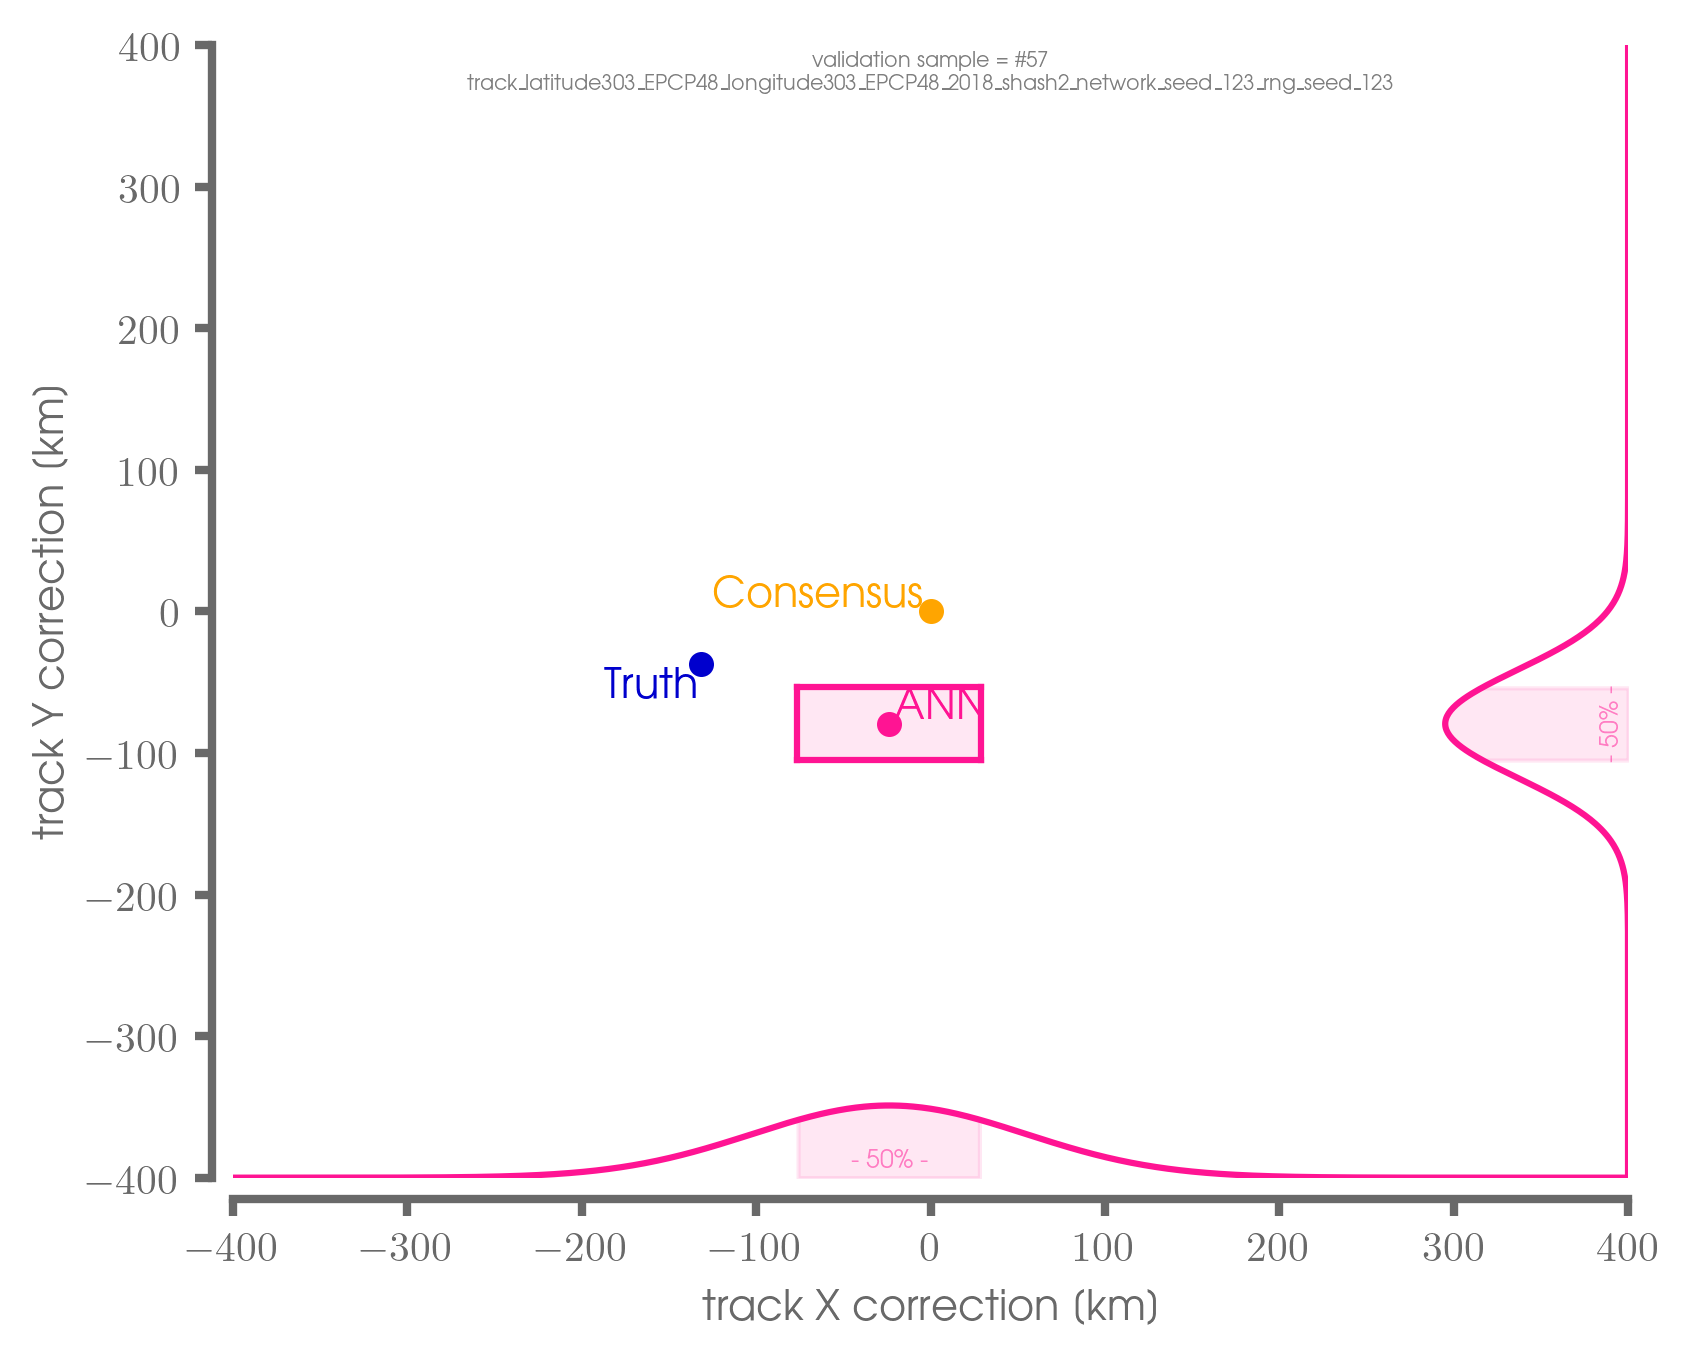

In [27]:
index = 57
bound = 400
scale = 10_000

#----------------------------------------------------------------
MS = 10
plt.figure(figsize=(6,5))
ax = plt.subplot(111)
format_spines(ax)

plt.plot(0,0,'.', color='orange', markersize=MS, label='Consensus')
plt.annotate("Consensus", (0,0), color='orange', xytext=(-5,5), textcoords='offset pixels', horizontalalignment='right')

plt.plot(true_correction_dx[index],true_correction_dy[index],'.',color='mediumblue', markersize=MS, label='Truth')
plt.annotate("Truth", (true_correction_dx[index],true_correction_dy[index]), color='mediumblue', xytext=(-2.5,-2.5), textcoords='offset pixels',horizontalalignment='right', verticalalignment='top')

plt.plot(ann_correction_dx[index],ann_correction_dy[index],'.', color='deeppink', markersize=MS, label='ANN')
plt.annotate("ANN", (ann_correction_dx[index],ann_correction_dy[index]), color='deeppink', xytext=(5,5), textcoords='offset pixels')

plt.plot((ann_low_correction_dx[index],ann_high_correction_dx[index]),(ann_low_correction_dy[index],ann_low_correction_dy[index]),'-', color='deeppink')
plt.plot((ann_low_correction_dx[index],ann_high_correction_dx[index]),(ann_high_correction_dy[index],ann_high_correction_dy[index]),'-', color='deeppink')
plt.plot((ann_low_correction_dx[index],ann_low_correction_dx[index]),(ann_low_correction_dy[index],ann_high_correction_dy[index]),'-', color='deeppink')
plt.plot((ann_high_correction_dx[index],ann_high_correction_dx[index]),(ann_low_correction_dy[index],ann_high_correction_dy[index]),'-', color='deeppink')

plt.fill([ann_low_correction_dx[index], 
          ann_high_correction_dx[index], 
          ann_high_correction_dx[index], 
          ann_low_correction_dx[index], 
          ann_low_correction_dx[index]], 
         [ann_low_correction_dy[index], 
          ann_low_correction_dy[index], 
          ann_high_correction_dy[index], 
          ann_high_correction_dy[index], 
          ann_low_correction_dy[index]
         ],color='deeppink',alpha=.1)

plt.xlim(-bound,bound)
plt.ylim(-bound,bound)

# plot the x-direction PDF
x = np.arange(-1000,1000)
shash_dist = shash_tfp.Shash(df['mu_pred_dx'][index], 
                       df['sigma_pred_dx'][index], 
                       df['gamma_pred_dx'][index], 
                       df['tau_pred_dx'][index],
                      )
d = -bound + scale*shash_dist.prob(x)
plt.plot(x,d,'-',color='deeppink')
x_shade = np.logical_and((x>=df['ann_low_correction_dx'][index]), (x<=df['ann_high_correction_dx'][index]))
plt.fill_between(x,d,-bound,x_shade, color='deeppink',alpha=.1)
plt.annotate("- 50\% -", (df['ann_low_correction_dx'][index]+df['iqr_dx'][index]/2,-bound), color='deeppink', alpha=.5,xytext=(0,5), fontsize=6, textcoords='offset pixels',horizontalalignment='center', verticalalignment='bottom')


# plot the y-direction PDF
x = np.arange(-1000,1000)
shash_dist = shash_tfp.Shash(df['mu_pred_dy'][index], 
                       df['sigma_pred_dy'][index], 
                       df['gamma_pred_dy'][index], 
                       df['tau_pred_dy'][index],
                      )
d = bound - scale*shash_dist.prob(x)
plt.plot(d,x,'-',color='deeppink')
x_shade = np.logical_and((x>=df['ann_low_correction_dy'][index]), (x<=df['ann_high_correction_dy'][index]))
plt.fill_betweenx(x,d,bound,x_shade, color='deeppink',alpha=.1)
plt.annotate("- 50\% -", (bound,df['ann_low_correction_dy'][index]+df['iqr_dy'][index]/2), color='deeppink', alpha=.5,xytext=(-5,0), fontsize=6, textcoords='offset pixels',horizontalalignment='right', verticalalignment='center', rotation=90)


plt.xlabel('track X correction [km] ')
plt.ylabel('track Y correction [km]')

ax = plt.gca()
plt.text(.5, .995, 'validation sample = \#' + str(index) + '\n' + MODEL_NAME,
    horizontalalignment='center',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    

plt.savefig(FIGURE_PATH + 'prediction_map_sample' + str(index) + '_' + MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()

# df_dx.iloc[index]

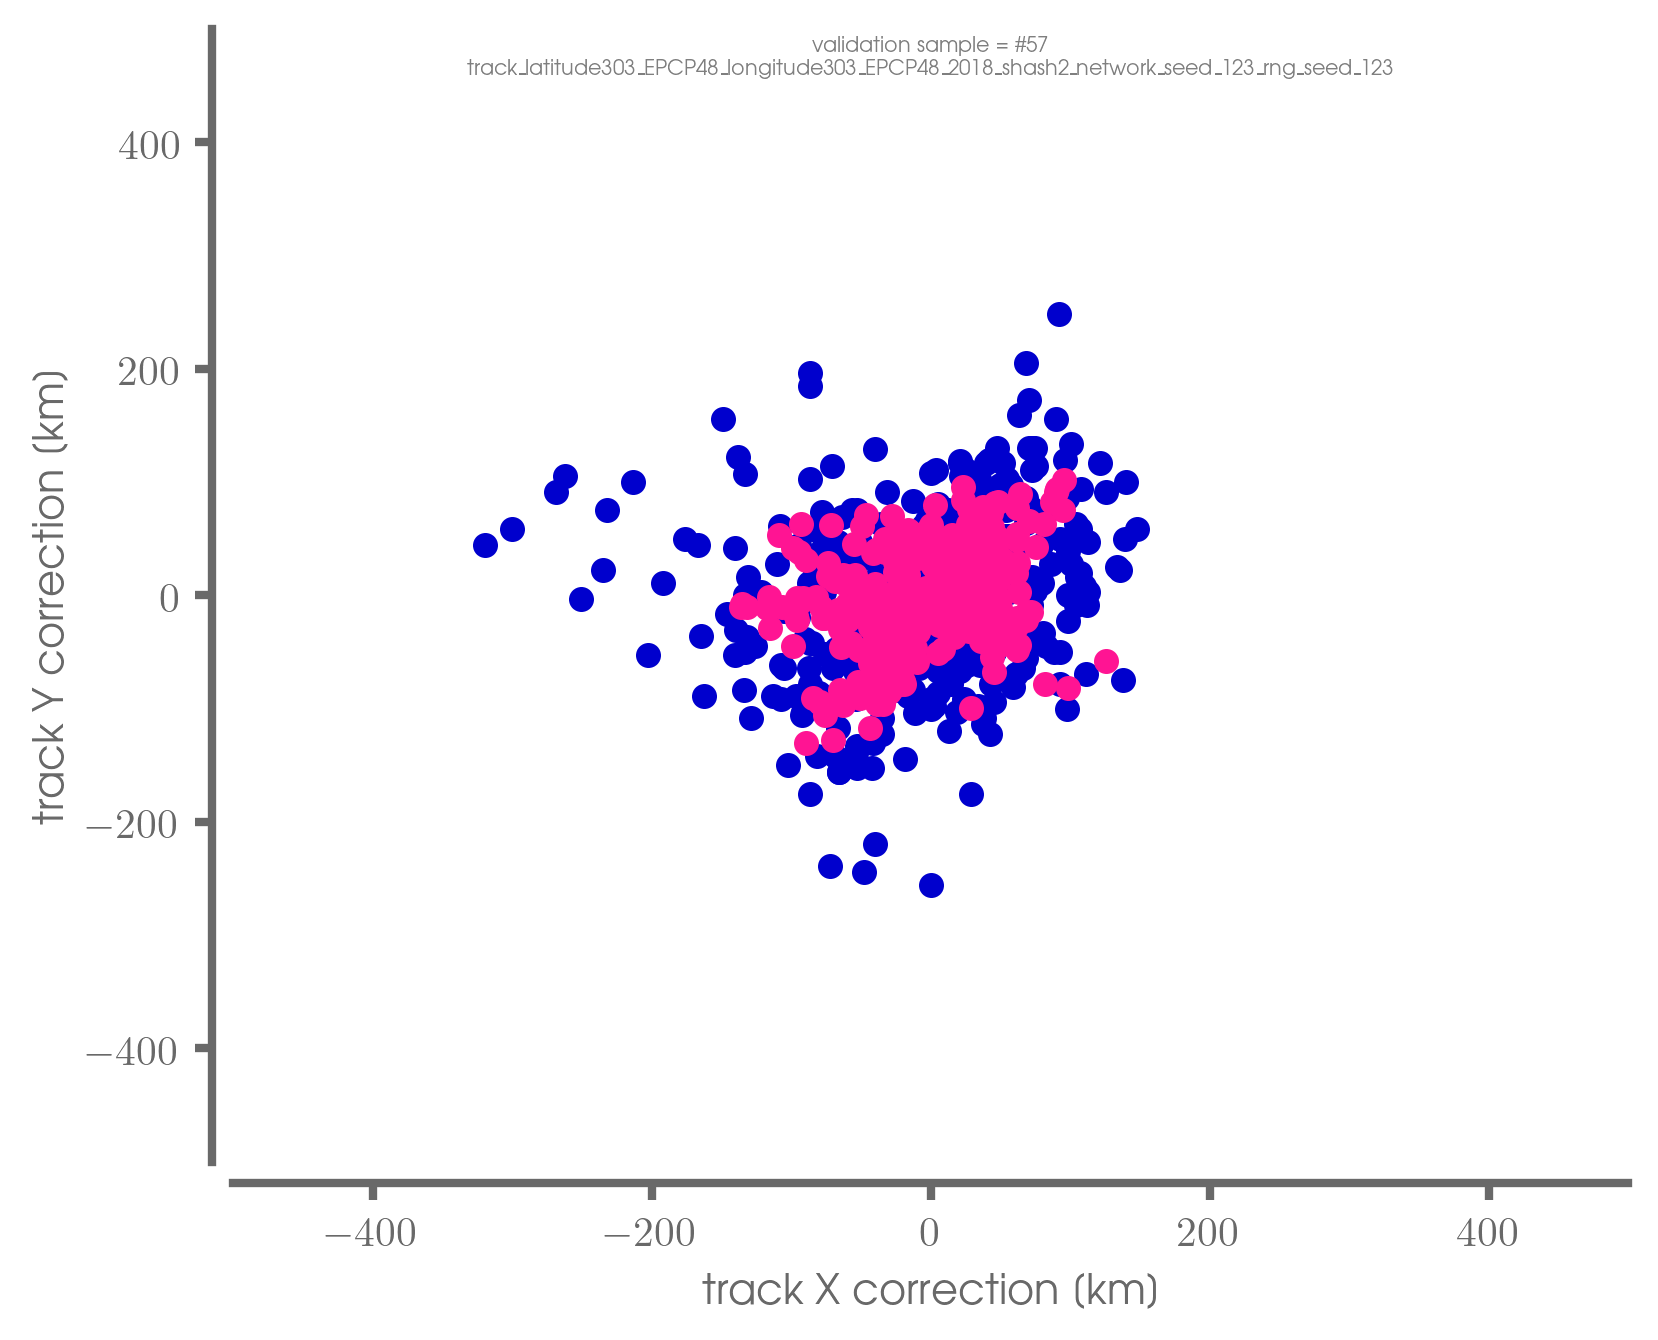

In [24]:
bound = 500
scale = 10_000

#----------------------------------------------------------------
MS = 10
plt.figure(figsize=(6,5))
ax = plt.subplot(111)
format_spines(ax)

plt.plot(0,0,'.', color='orange', markersize=MS, label='Consensus')

plt.plot(true_correction_dx,true_correction_dy,'.',color='mediumblue', markersize=MS, label='Truth')

plt.plot(ann_correction_dx,ann_correction_dy,'.', color='deeppink', markersize=MS, label='ANN')



plt.xlim(-bound,bound)
plt.ylim(-bound,bound)


plt.xlabel('track X correction [km] ')
plt.ylabel('track Y correction [km]')

ax = plt.gca()
plt.text(.5, .995, 'validation sample = \#' + str(index) + '\n' + MODEL_NAME,
    horizontalalignment='center',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    

# plt.savefig(FIGURE_PATH + 'prediction_map_sample' + str(index) + '_' + MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()

# df_dx.iloc[index]

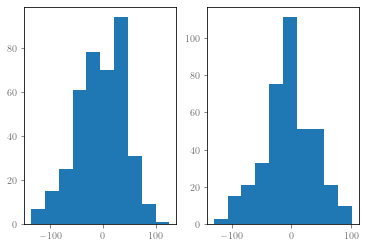

In [13]:
plt.subplot(1,2,1)
plt.hist(ann_correction_dx)

plt.subplot(1,2,2)
plt.hist(ann_correction_dy)


plt.show()

### Errors vs uncertainty estimates

In [14]:
def plot_iqr_vs_error(ax, model, x_eval, onehot_eval, df_eval, yvar="shash_error"):
    # make predictions
    mu_pred, sigma_pred, gamma_pred, tau_pred = prediction.params(x_eval, model)    

    # convert y_pred to intensity corrections    
    ann_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.5)
    true_correction =  onehot_eval[:,0]

    # compute errors
    shash_error  = np.abs(ann_correction - true_correction)

    # covert shash prediction bounds
    shash_low_correction  = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.25)
    shash_high_correction = prediction.percentile_value(mu_pred,sigma_pred,gamma_pred,tau_pred,percentile_frac=.75)
    iqr                   = shash_high_correction - shash_low_correction

    print(stats.spearmanr(iqr,shash_error))
    print(stats.pearsonr(iqr,shash_error))

    df_eval['iqr'] = iqr
    df_eval['shash_error'] = shash_error

    #------------------------------------------------------------------------------------
    ROUND_BASE = 50

    df_plot = df_eval.copy()
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: custom_round(x, base=ROUND_BASE))
    df_plot['iqr'] = pd.Series(df_plot['iqr']).apply(lambda x: ceiling_round(x, ceiling=200))
    #-----------------------------------------------------------------------------
    clr = colors[0]
    
    for xvar in ('iqr',):#('sigma', 'range_66'):
        g = sns.boxplot(
            ax=ax,
            data=df_plot,
            x=xvar, y=yvar,
            whis=None,
            fliersize=0,
            boxprops={'alpha':.2,
                      'edgecolor': 'gray',
                      'color': 'gray',
                     },
        )      
        plt.setp(g.artists, edgecolor = '.4', facecolor='.95')
        plt.setp(g.lines, color='.4')
        ax = sns.stripplot(ax=ax,x=xvar, y=yvar, data=df_plot, color=clr, size=3.,alpha=.75,)
        # plt.axhline(y=0,color='k', alpha=.25, linewidth=1)

        # g.set_xlim(-.5,6.5)

        ax.set_xlabel('Predicted IQR [km]')
        ax.set_title('(a) SHASH Error vs SHASH Predicted Uncertainty', fontsize=FS*.9, color='k')            
        ax.set_ylabel('Absolute Error [km]')        



SpearmanrResult(correlation=0.17344448681667987, pvalue=2.237499112111856e-05)
(0.22195419887357018, 4.965371377489134e-08)
SpearmanrResult(correlation=0.07843088527415062, pvalue=0.0567030461647923)
(0.21903943623848182, 7.484276829181713e-08)


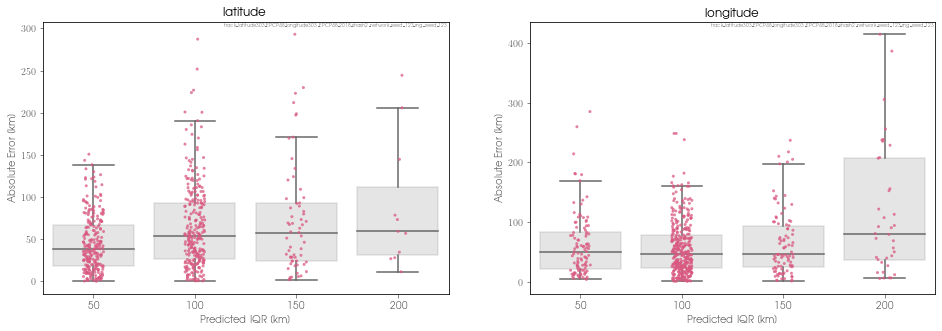

In [15]:
from toolbox import custom_round, ceiling_round

f, axs = plt.subplots(1, 2, figsize=(16,5))

# latitude
ax = axs[0]
plot_iqr_vs_error(ax, model_dy, x_valtest_dy, onehot_valtest_dy, df_valtest_dy, yvar="shash_error")
plt.text(.995, .995, MODEL_NAME,
    horizontalalignment='right',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    
ax.set_title('latitude')

# longitude
ax = axs[1]
plot_iqr_vs_error(ax, model_dx, x_valtest_dx, onehot_valtest_dx, df_valtest_dx, yvar="shash_error")
plt.text(.995, .995, MODEL_NAME,
    horizontalalignment='right',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)   
ax.set_title('longitude')


plt.savefig(FIGURE_PATH + 'error_vs_uq_boxplot_' +  MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()

### ANN prediction of Consensus Error

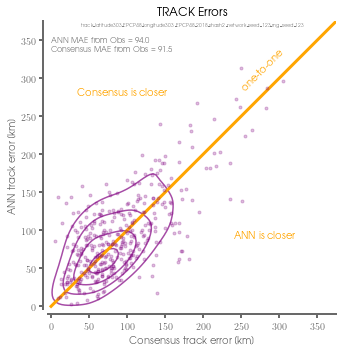

In [16]:
import scipy.stats as stats

if(EXP_NAME_dx[-2:]=='72'):
    bound=625
    inc = .000005
else:
    bound=375
    inc = .00002


plt.figure(figsize=(5,5))
ax = plt.gca()
adjust_spines(ax, ['left', 'bottom'])
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['left'].set_color('dimgrey')
ax.spines['bottom'].set_color('dimgrey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params('both',length=4,width=2,which='major',color='dimgrey')

# Peform the kernel density estimate
x = df['cons_error']
y = df['ann_error']
xmin, xmax = -1000, 1000
ymin, ymax = -1000, 1000

xx, yy = np.mgrid[xmin:xmax:500j, ymin:ymax:500j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([x, y])
kernel = stats.gaussian_kde(values,bw_method='scott')
f = np.reshape(kernel(positions).T, xx.shape)


cfset = plt.contour(xx, yy, f, levels=np.arange(inc,.0005,inc), colors='purple', alpha=.7)
plt.plot((0,1000),(0,1000),'-',color='orange',linewidth=3.)
plt.annotate("one-to-one", (bound*.75,bound*.75), color='orange', alpha=1.,xytext=(-25,0), fontsize=10, textcoords='offset pixels',horizontalalignment='left', verticalalignment='bottom', rotation=45)
plt.plot(df['cons_error'],df['ann_error'],'.',color='purple',alpha=.25)

plt.xlim(-0.01*bound,bound)
plt.ylim(-0.01*bound,bound)

plt.annotate("ANN is closer", (bound*.75,bound*.25), color='orange', alpha=1.,xytext=(0,0), fontsize=10, textcoords='offset pixels',horizontalalignment='center', verticalalignment='center')
plt.annotate("Consensus is closer", (bound*.25,bound*.75), color='orange', alpha=1.,xytext=(0,0), fontsize=10, textcoords='offset pixels',horizontalalignment='center', verticalalignment='center')

plt.ylabel('ANN track error [km]')
plt.xlabel('Consensus track error [km]')
plt.title('TRACK Errors')

plt.text(.5, .995, MODEL_NAME,
    horizontalalignment='center',
    verticalalignment='top',
    color='tab:gray',
    fontsize=5,
    transform = ax.transAxes)    

t = 'ANN MAE from Obs           = ' + str(np.round(ann_mae,1)) + '\nConsensus MAE from Obs = ' + str(np.round(cons_mae,1))
plt.text(.01,.95,t,
    horizontalalignment='left',
    verticalalignment='top',
    color='tab:gray',
    fontsize=8,
    transform = ax.transAxes)  

ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIGURE_PATH + 'prediction_vs_actual_' + MODEL_NAME + '.png', dpi=dpiFig)    
plt.show()